In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as ny

In [2]:
orders = pd.read_csv(r"C:\Users\subho\Downloads\archive (1)\olist_orders_dataset.csv")

In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [6]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [7]:
orders.groupby('order_status').agg({
    'order_approved_at':'count',
    'order_delivered_carrier_date':'count',
    'order_delivered_customer_date':'count'
})

,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
order_status,,,
approved,2,0,0
canceled,484,75,6
created,0,0,0
delivered,96464,96476,96470
invoiced,314,0,0
processing,301,0,0
shipped,1107,1107,0
unavailable,609,0,0


In [8]:
orders[
    (orders['order_approved_at'].isna()) &
    (orders['order_delivered_customer_date'].isna()) &
    (orders['order_delivered_carrier_date'].isna())
]['order_status'].value_counts()

order_status
canceled    141
created       5
Name: count, dtype: int64

In [9]:
orders[orders['order_approved_at'].isna()]['order_status'].value_counts()

order_status
canceled     141
delivered     14
created        5
Name: count, dtype: int64

In [10]:
orders[orders['order_delivered_carrier_date'].isna()]['order_status'].value_counts()

order_status
unavailable    609
canceled       550
invoiced       314
processing     301
created          5
approved         2
delivered        2
Name: count, dtype: int64

In [11]:
orders[orders['order_delivered_customer_date'].isna()]['order_status'].value_counts()

order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

#
Orders with canceled or unavailable status often lack approval and delivery timestamps because they did not progress beyond the early order stages.

Orders marked as shipped but missing delivery timestamps likely represent items still in transit or awaiting delivery confirmation.

A small number of delivered orders missing approval or delivery timestamps indicate minor data inconsistencies in the system records.

In [12]:
 # Orders delivered but have no approval time.
orders[
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isna())
].shape[0]

14

In [13]:
 # Remove orders that were delivered but have no approval time.

orders = orders[~(
    (orders['order_status'] == 'delivered') &
    (orders['order_approved_at'].isna())
)]

In [14]:
# Remove Delivered Orders Without Delivery Date

In [15]:
# Orders delivered but have no delivery date.

orders[(orders['order_status'] == 'delivered') &
    (orders["order_delivered_customer_date"].isna())
    ].shape[0]

8

In [16]:
orders = orders[~((orders['order_status'] == 'delivered') &
    (orders["order_delivered_customer_date"].isna())
        )]

In [17]:
orders['purchase_year'] = orders['order_purchase_timestamp'].dt.year
orders['purchase_month'] = orders['order_purchase_timestamp'].dt.month
orders['purchase_day'] = orders['order_purchase_timestamp'].dt.day
orders['purchase_weekday'] = orders['order_purchase_timestamp'].dt.day_name()

In [18]:
orders['delivery_time'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

In [19]:
orders['delivery_time'].describe()

count    96462.000000
mean        12.093996
std          9.552390
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_time, dtype: float64

In [20]:
orders['processing_time'] = (
    orders['order_approved_at'] -
    orders['order_purchase_timestamp']
).dt.total_seconds() / 3600

In [21]:
orders['processing_time'].describe()

count    99273.000000
mean        10.419913
std         26.038893
min          0.000000
25%          0.215000
50%          0.343333
75%         14.581944
max       4509.180556
Name: processing_time, dtype: float64

In [22]:
orders['delivery_delay'] = (
    orders['order_delivered_customer_date'] -
    orders['order_estimated_delivery_date']
).dt.days

In [23]:
def delivery_status(x):
    if pd.isna(x):
        return None
    elif x < 0:
        return "Early"
    elif x == 0:
        return "On Time"
    else:
        return "Late"

orders['delivery_status'] = orders['delivery_delay'].apply(delivery_status)

In [24]:
orders['delivery_delay'].describe()

count    96462.000000
mean       -11.875391
std         10.183586
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay, dtype: float64

In [25]:
orders["is_late"] = orders["delivery_delay"]>0

In [26]:
orders["is_late"].value_counts()

is_late
False    92884
True      6535
Name: count, dtype: int64

In [27]:
# About 89% of orders were delivered earlier than the estimated delivery date, while only about 9.5% experienced delays.

In [28]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day,purchase_weekday,delivery_time,processing_time,delivery_delay,delivery_status,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,Monday,8.0,0.178333,-8.0,Early,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,Tuesday,13.0,30.713889,-6.0,Early,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,Wednesday,9.0,0.276111,-18.0,Early,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,18,Saturday,13.0,0.298056,-13.0,Early,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,13,Tuesday,2.0,1.030556,-10.0,Early,False


In [29]:
products = pd.read_csv(r"C:\Users\subho\Downloads\archive (1)\olist_products_dataset.csv")

In [30]:
products.isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [31]:
products['product_category_name'].fillna('unknown', inplace=True)


C:\Users\subho\AppData\Local\Temp\ipykernel_44980\1217598219.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products['product_category_name'].fillna('unknown', inplace=True)


In [32]:
products['product_volume_cm3'] = (
    products['product_length_cm'] *
    products['product_height_cm'] *
    products['product_width_cm']
)

In [33]:
def size_category(v):
    if v < 1000:
        return 'small'
    elif v < 10000:
        return 'medium'
    else:
        return 'large'

products['size_category'] = products['product_volume_cm3'].apply(size_category)

In [34]:
products['size_category'].value_counts()

size_category
medium    17887
large     12859
small      2205
Name: count, dtype: int64

In [35]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_volume_cm3,size_category
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,2240.0,medium
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,10800.0,large
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,2430.0,medium
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,2704.0,medium
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,4420.0,medium


In [36]:
seller = pd.read_csv(r"C:\Users\subho\Downloads\archive (1)\olist_sellers_dataset.csv")

In [37]:
seller.isnull().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [38]:
seller.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [39]:
product = pd.read_csv(r"C:\Users\subho\Downloads\archive (1)\product_category_name_translation.csv")

In [40]:
product.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [41]:
product.isnull().sum()

product_category_name            0
product_category_name_english    0
dtype: int64

In [42]:
geolocation = pd.read_csv(r"C:\Users\subho\Downloads\archive (1)\olist_geolocation_dataset.csv")

In [43]:
geolocation.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [44]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [45]:
geolocation['geolocation_zip_code_prefix'] = geolocation['geolocation_zip_code_prefix'].astype(str)
geolocation['geolocation_zip_code_prefix'] = geolocation['geolocation_zip_code_prefix'].str.zfill(5)

In [46]:
geolocation.isnull().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [47]:
geolocation.duplicated().sum()

np.int64(261831)

In [48]:
geolocation[geolocation.duplicated()]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,01046,-23.546081,-46.644820,sao paulo,SP
44,01046,-23.546081,-46.644820,sao paulo,SP
65,01046,-23.546081,-46.644820,sao paulo,SP
66,01009,-23.546935,-46.636588,sao paulo,SP
67,01046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [49]:
geolocation['geolocation_city'] = geolocation['geolocation_city'].str.lower().str.strip()

In [50]:
import unicodedata
def normalize_city(text):
    return unicodedata.normalize('NFKD', text).encode('ascii','ignore').decode('utf-8')
geolocation['geolocation_city'] = geolocation['geolocation_city'].apply(normalize_city)

In [51]:
geolocation_clean = geolocation.drop_duplicates()

In [52]:
geolocation_final = geolocation_clean.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean',
    'geolocation_city': 'first',
    'geolocation_state': 'first'
}).reset_index()

In [53]:
order_items = pd.read_csv(r"C:\Users\subho\Downloads\archive (1)\olist_order_items_dataset.csv")

In [54]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [55]:
order_items['shipping_limit_date'] = pd.to_datetime(order_items['shipping_limit_date'])
order_items['total_item_price'] = order_items['price'] + order_items['freight_value']

In [56]:
order_items.isnull().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
total_item_price       0
dtype: int64

In [57]:
order_items['shipping_limit_date'].dt.year.value_counts()

shipping_limit_date
2018    62511
2017    49765
2016      370
2020        4
Name: count, dtype: int64

In [58]:
order_items = order_items[order_items['shipping_limit_date'].dt.year <= 2018]
'''
Four records with shipping_limit_date in 2020 were identified as anomalies since the dataset primarily spans from 2016 to 2018.
These records were removed to maintain temporal consistency in the analysis.
'''

'\nFour records with shipping_limit_date in 2020 were identified as anomalies since the dataset primarily spans from 2016 to 2018.\nThese records were removed to maintain temporal consistency in the analysis.\n'

In [59]:
order_items.describe()

,order_item_id,shipping_limit_date,price,freight_value,total_item_price
count,112646.000000,112646,112646.000000,112646.000000,112646.000000
mean,1.197832,2018-01-07 14:56:26.712683776,120.654952,19.989678,140.644630
min,1.000000,2016-09-19 00:15:34,0.850000,0.000000,6.080000
25%,1.000000,2017-09-20 20:55:12,39.900000,13.080000,55.220000
50%,1.000000,2018-01-26 13:59:30,74.990000,16.260000,92.320000
75%,1.000000,2018-05-10 14:30:19,134.900000,21.150000,157.927500
max,21.000000,2018-09-18 21:10:15,6735.000000,409.680000,6929.310000
std,0.705132,NaN,183.637058,15.805705,190.727629


In [60]:
customers = pd.read_csv(r"C:\Users\subho\Downloads\archive (1)\olist_customers_dataset.csv")

In [61]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [62]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [63]:
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str)

In [64]:
customers['customer_zip_code_prefix'].str.len().value_counts()


customer_zip_code_prefix
5    75446
4    23995
Name: count, dtype: int64

In [65]:
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].str.zfill(5)

In [66]:
customers.isnull().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [67]:
customers.duplicated().sum()

np.int64(0)

In [68]:
# Group the unique IDs to see how many orders each person placed.
order_counts = customers.groupby('customer_unique_id')['customer_id'].count()
order_distribution = order_counts.value_counts().sort_index()
print(order_distribution)

customer_id
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64


In [69]:
payments = pd.read_csv(r"C:\Users\subho\Downloads\archive (1)\olist_order_payments_dataset.csv")

In [70]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [71]:
payments.isnull().sum()

order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

In [72]:
payments.duplicated().sum()

np.int64(0)

In [73]:
payments[payments['payment_value']==0]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
19922,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.0
36822,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.0
43744,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.0
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
62674,45ed6e85398a87c253db47c2d9f48216,3,voucher,1,0.0
77885,fa65dad1b0e818e3ccc5cb0e39231352,13,voucher,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0
100766,b23878b3e8eb4d25a158f57d96331b18,4,voucher,1,0.0


In [74]:
# Removing zero payment value orders for revenue analysis
payment_revenue_analysis = payments[payments["payment_value"] > 0]

In [75]:
payment_revenue_analysis.describe()

,payment_sequential,payment_installments,payment_value
count,103877.000000,103877.000000,103877.000000
mean,1.092340,2.853509,154.113732
std,0.704312,2.687112,217.498755
min,1.000000,0.000000,0.010000
25%,1.000000,1.000000,56.820000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.840000
max,29.000000,24.000000,13664.080000


In [76]:
payments.payment_type.value_counts()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [77]:
payments[payments["payment_type"] == "not_defined"]

,order_id,payment_sequential,payment_type,payment_installments,payment_value
51280,4637ca194b6387e2d538dc89b124b0ee,1,not_defined,1,0.0
57411,00b1cb0320190ca0daa2c88b35206009,1,not_defined,1,0.0
94427,c8c528189310eaa44a745b8d9d26908b,1,not_defined,1,0.0


In [78]:
payments["payment_type"] = payments["payment_type"].replace("not_defined", "unknown")

In [79]:
reviews = pd.read_csv(r"C:\Users\subho\Downloads\archive (1)\olist_order_reviews_dataset.csv")

In [80]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [81]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [82]:
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp'] = pd.to_datetime(reviews['review_answer_timestamp'])

In [83]:
reviews.isnull().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [84]:
reviews.duplicated().sum()

np.int64(0)

In [85]:
reviews['review_score'].unique()

array([4, 5, 1, 3, 2])

In [86]:
reviews.groupby('review_score')['review_comment_message'].count()

review_score
1     8745
2     2145
3     3557
4     5976
5    20554
Name: review_comment_message, dtype: int64

In [87]:
reviews[reviews.isna().any(axis = 1)]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [88]:
reviews.groupby('review_score')['review_comment_message'].apply(lambda x: x.notnull().mean())

review_score
1    0.765494
2    0.680736
3    0.434894
4    0.312193
5    0.358533
Name: review_comment_message, dtype: float64

In [89]:
reviews['review_length'] = reviews['review_comment_message'].str.len()

In [90]:
reviews.groupby('review_score')['review_length'].mean()

review_score
1    99.941910
2    96.845688
3    83.331740
4    61.733601
5    51.839496
Name: review_length, dtype: float64

In [91]:
reviews['response_time_in _days'] = (
    reviews['review_answer_timestamp'] -
    reviews['review_creation_date']
).dt.days

In [92]:
check = orders.merge(
    payments,
    on='order_id',
    how='outer',
    indicator=True
)

check.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,delivery_time,processing_time,delivery_delay,delivery_status,is_late,payment_sequential,payment_type,payment_installments,payment_value,_merge
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,2017.0,9.0,...,7.0,0.775833,-9.0,Early,False,1.0,credit_card,2.0,72.19,both
1,00018f77f2f0320c557190d7a144bdd3,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,2017.0,4.0,...,16.0,0.201944,-3.0,Early,False,1.0,credit_card,3.0,259.83,both
2,000229ec398224ef6ca0657da4fc703e,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,2018.0,1.0,...,7.0,0.249722,-14.0,Early,False,1.0,credit_card,5.0,216.87,both
3,00024acbcdf0a6daa1e931b038114c75,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,2018.0,8.0,...,6.0,0.161944,-6.0,Early,False,1.0,credit_card,2.0,25.78,both
4,00042b26cf59d7ce69dfabb4e55b4fd9,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,2017.0,2.0,...,25.0,0.206111,-16.0,Early,False,1.0,credit_card,3.0,218.04,both


In [93]:
check = orders.merge(
    payments,
    on='order_id',
    how='outer',
    indicator=True
)

In [94]:
(check['_merge'] == 'left_only').sum()

np.int64(1)

In [95]:
(check['_merge'] == 'right_only').sum()

np.int64(22)

### Data Validation

Cross-table validation was performed using `order_id` relationships.

A small number of unmatched records were identified:
- 1 order record without corresponding payment information
- 22 payment records without matching order entries

Given the extremely small proportion relative to the overall dataset size, 
these inconsistencies were considered negligible and retained as part of 
real-world data irregularities.

In [96]:
products['product_category_name'].isnull().sum()

np.int64(0)

In [97]:
products['product_category_name'].unique()

array(['perfumaria', 'artes', 'esporte_lazer', 'bebes',
       'utilidades_domesticas', 'instrumentos_musicais', 'cool_stuff',
       'moveis_decoracao', 'eletrodomesticos', 'brinquedos',
       'cama_mesa_banho', 'construcao_ferramentas_seguranca',
       'informatica_acessorios', 'beleza_saude', 'malas_acessorios',
       'ferramentas_jardim', 'moveis_escritorio', 'automotivo',
       'eletronicos', 'fashion_calcados', 'telefonia', 'papelaria',
       'fashion_bolsas_e_acessorios', 'pcs', 'casa_construcao',
       'relogios_presentes', 'construcao_ferramentas_construcao',
       'pet_shop', 'eletroportateis', 'agro_industria_e_comercio',
       'unknown', 'moveis_sala', 'sinalizacao_e_seguranca',
       'climatizacao', 'consoles_games', 'livros_interesse_geral',
       'construcao_ferramentas_ferramentas',
       'fashion_underwear_e_moda_praia', 'fashion_roupa_masculina',
       'moveis_cozinha_area_de_servico_jantar_e_jardim',
       'industria_comercio_e_negocios', 'telefonia_fixa

In [98]:
customers['customer_state'].unique()

array(['SP', 'SC', 'MG', 'PR', 'RJ', 'RS', 'PA', 'GO', 'ES', 'BA', 'MA',
       'MS', 'CE', 'DF', 'RN', 'PE', 'MT', 'AM', 'AP', 'AL', 'RO', 'PB',
       'TO', 'PI', 'AC', 'SE', 'RR'], dtype=object)

# Cohort Analysis

In [99]:
cohort_df = orders.merge(
    customers[['customer_id', 'customer_unique_id']],
    on='customer_id',
    how='left'
)

In [100]:
cohort_df['order_purchase_timestamp'] = pd.to_datetime(
    cohort_df['order_purchase_timestamp']
)

In [101]:
cohort_df['order_month'] = (
    cohort_df['order_purchase_timestamp']
    .dt.to_period('M')
)

In [102]:
cohort_df['cohort_month'] = (
    cohort_df.groupby('customer_unique_id')['order_month']
    .transform('min')
)

In [103]:
cohort_df['cohort_index'] = (
    (cohort_df['order_month'].dt.year -
     cohort_df['cohort_month'].dt.year) * 12
    +
    (cohort_df['order_month'].dt.month -
     cohort_df['cohort_month'].dt.month)
)

In [104]:
cohort_data = cohort_df.groupby(
    ['cohort_month', 'cohort_index']
)['customer_unique_id'].nunique().reset_index()

In [105]:
cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_unique_id'
)

In [106]:
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(
    cohort_size,
    axis=0
)

In [107]:
retention = (retention * 100).round(1)

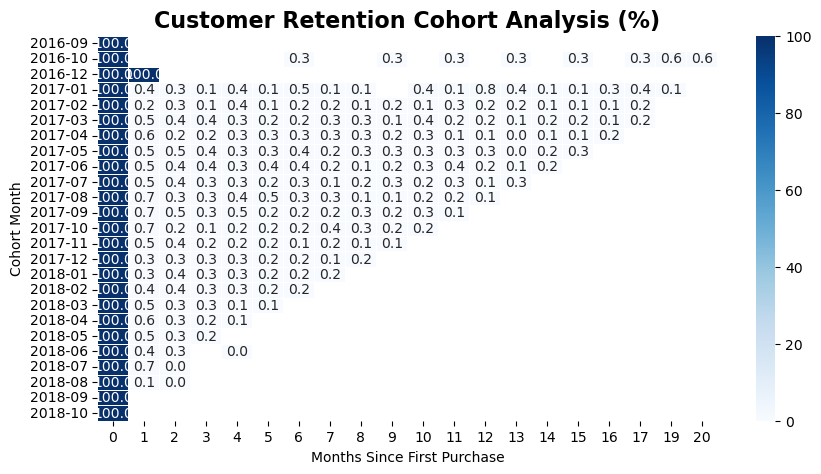

In [113]:
plt.figure(figsize=(10,5))

sns.heatmap(
    retention,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5
)

plt.title(
    'Customer Retention Cohort Analysis (%)',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')

plt.show()

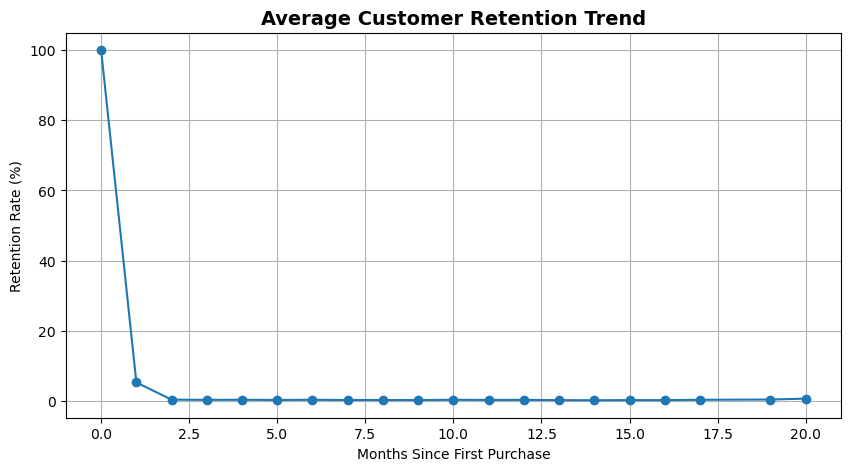

In [109]:
# Average retention by cohort index

avg_retention = retention.mean()

plt.figure(figsize=(10,5))

plt.plot(
    avg_retention.index,
    avg_retention.values,
    marker='o'
)

plt.title(
    'Average Customer Retention Trend',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Months Since First Purchase')
plt.ylabel('Retention Rate (%)')

plt.grid(True)

plt.show()

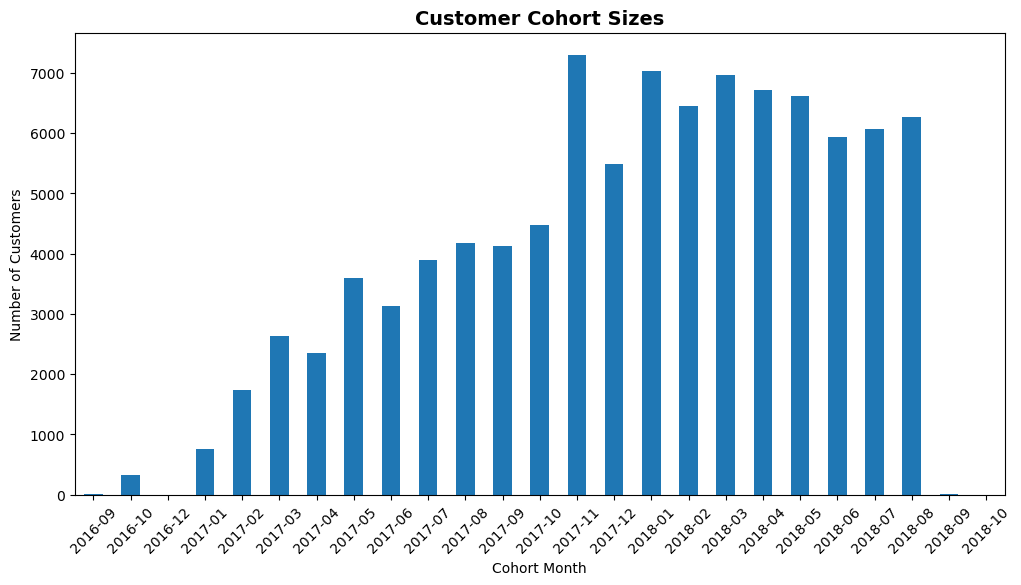

In [110]:
# Cohort sizes

cohort_sizes = cohort_pivot.iloc[:,0]

plt.figure(figsize=(12,6))

cohort_sizes.plot(kind='bar')

plt.title(
    'Customer Cohort Sizes',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Cohort Month')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

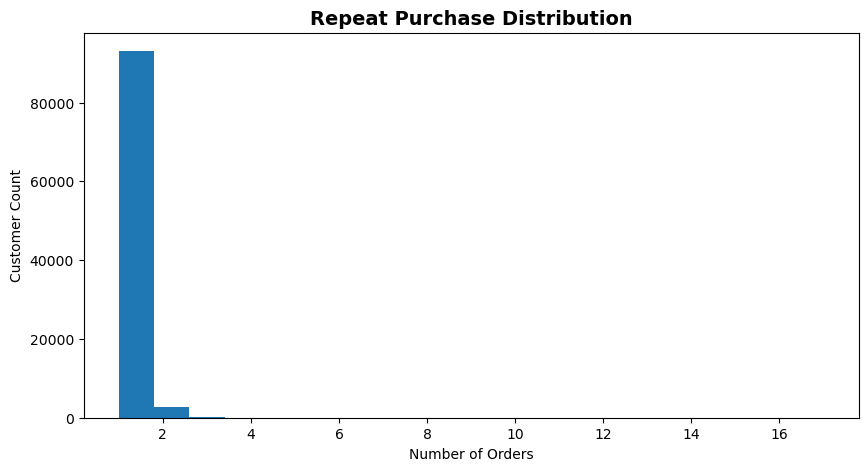

In [111]:
repeat_orders = cohort_df.groupby(
    'customer_unique_id'
)['order_id'].nunique()

plt.figure(figsize=(10,5))

plt.hist(
    repeat_orders,
    bins=20
)

plt.title(
    'Repeat Purchase Distribution',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Number of Orders')
plt.ylabel('Customer Count')

plt.show()

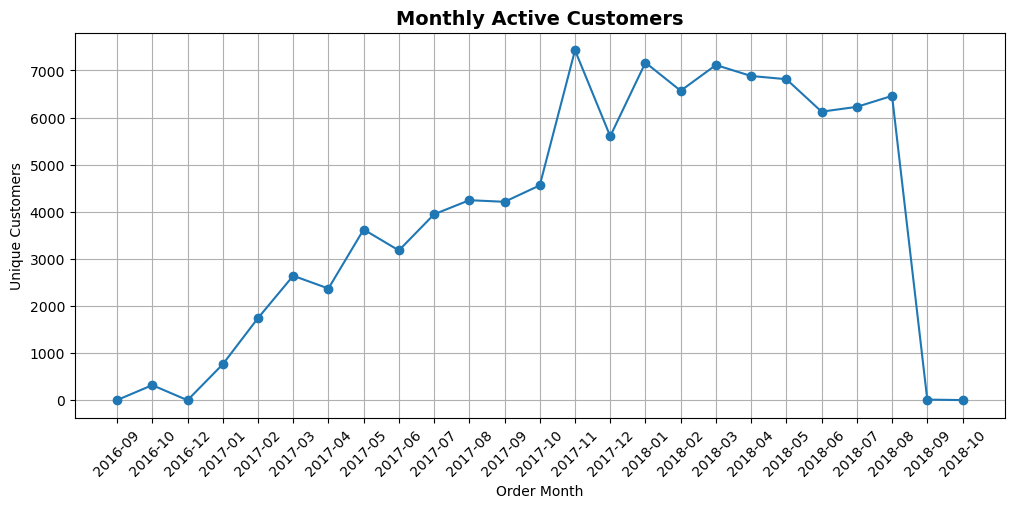

In [112]:
monthly_repeat = cohort_df.groupby(
    'order_month'
)['customer_unique_id'].nunique()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_repeat.index.astype(str),
    monthly_repeat.values,
    marker='o'
)

plt.title(
    'Monthly Active Customers',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('Order Month')
plt.ylabel('Unique Customers')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

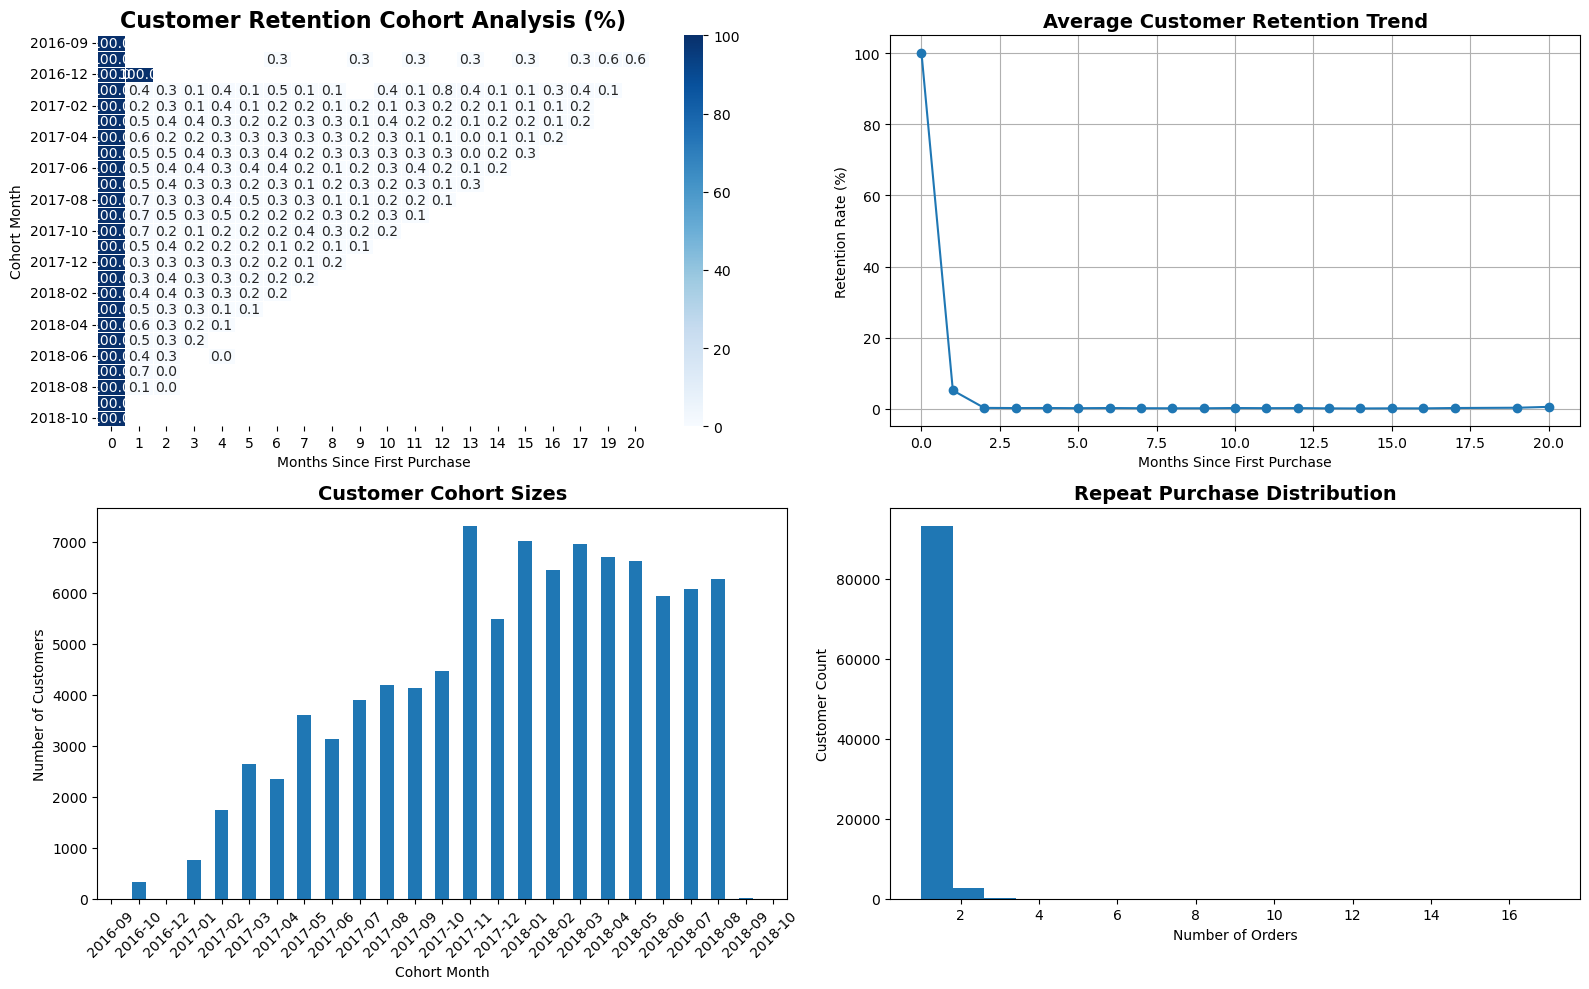

In [119]:
# ==============================
# CUSTOMER RETENTION DASHBOARD
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(16,10))

# --------------------------------
# 1. Retention Heatmap
# --------------------------------

sns.heatmap(
    retention,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    ax=axes[0,0]
)

axes[0,0].set_title(
    'Customer Retention Cohort Analysis (%)',
    fontsize=16,
    fontweight='bold'
)

axes[0,0].set_xlabel('Months Since First Purchase')
axes[0,0].set_ylabel('Cohort Month')

# --------------------------------
# 2. Average Retention Trend
# --------------------------------

avg_retention = retention.mean()

axes[0,1].plot(
    avg_retention.index,
    avg_retention.values,
    marker='o'
)

axes[0,1].set_title(
    'Average Customer Retention Trend',
    fontsize=14,
    fontweight='bold'
)

axes[0,1].set_xlabel('Months Since First Purchase')
axes[0,1].set_ylabel('Retention Rate (%)')

axes[0,1].grid(True)

# --------------------------------
# 3. Cohort Sizes
# --------------------------------

cohort_sizes = cohort_pivot.iloc[:,0]

cohort_sizes.plot(
    kind='bar',
    ax=axes[1,0]
)

axes[1,0].set_title(
    'Customer Cohort Sizes',
    fontsize=14,
    fontweight='bold'
)

axes[1,0].set_xlabel('Cohort Month')
axes[1,0].set_ylabel('Number of Customers')

axes[1,0].tick_params(axis='x', rotation=45)

# --------------------------------
# 4. Repeat Purchase Distribution
# --------------------------------

repeat_orders = cohort_df.groupby(
    'customer_unique_id'
)['order_id'].nunique()

axes[1,1].hist(
    repeat_orders,
    bins=20
)

axes[1,1].set_title(
    'Repeat Purchase Distribution',
    fontsize=14,
    fontweight='bold'
)

axes[1,1].set_xlabel('Number of Orders')
axes[1,1].set_ylabel('Customer Count')

# --------------------------------
# FINAL LAYOUT
# --------------------------------

plt.tight_layout()

plt.show()